In [1]:
from datasets import Dataset
import json
from sklearn.model_selection import train_test_split
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
project_root = os.path.abspath("..")
sys.path.insert(0, project_root)

In [3]:
aoetoshort = {"CapeBonAlexandria": "CBA", "GulfLion": "GL", "TyrrhenianCoastIT": "TC"}


In [4]:
with open(project_root + "/params.json", 'r') as f:
    PARAMS = json.load(f)

In [5]:
with open(project_root + "/id2aoe.json", 'r') as f:
    id2aoe = json.load(f)

with open(project_root + "/id2name.json", 'r') as f:
    id2name = json.load(f)

In [6]:
all_ports_aoe_topos = pd.read_csv(PARAMS["all_ports_aoe_topos"])
dataset = Dataset.load_from_disk(f'{PARAMS["roberta_data_path"]}_{PARAMS["word_window"]}_filtered').to_pandas()
all_excerpts = Dataset.load_from_disk(PARAMS["dataset_extracted"]).to_pandas()

In [7]:
labels = dataset["label"].unique()

label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in enumerate(labels)}

dataset["dlabel"] = [label2id[x] for x in dataset["label"]]

In [8]:
train_data, test_data = train_test_split(dataset, train_size=0.8, stratify=dataset["dlabel"] , random_state=42)
test_data, val_data = train_test_split(test_data, train_size=0.5, stratify=test_data["dlabel"], random_state=42)

In [9]:
train_data["split"] = "train"
test_data["split"] = "test"
val_data["split"] = "val"
dataset = pd.concat([train_data, test_data, val_data])
dataset["AOE"] = [id2aoe[str(x)] for x in dataset["newOBJECTID"]]
dataset["name"] = [id2name[str(x)] for x in dataset["newOBJECTID"]]

In [10]:
dataset["name_short"] = [f'{x.split(",")[0]} ({aoetoshort[y]})' for x, y in zip(dataset["name"], dataset["AOE"])]
dataset_short = dataset[["name_short", "AOE", "split", "label"]]


In [11]:
check_repeats = dataset.groupby(["name", "label", "AOE"]).count().reset_index()
check_repeats["dupe"] = check_repeats.duplicated(subset=["name"])

len(check_repeats[check_repeats["dupe"]==True])

0

In [12]:
SMALL_SIZE = 12
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title


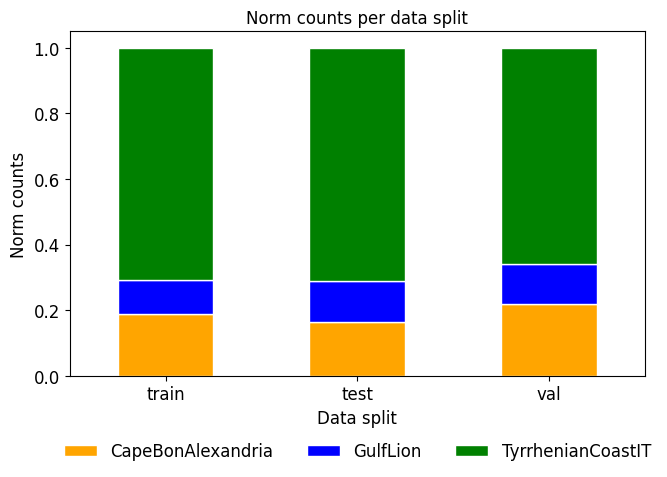

In [13]:
# Consistent split order
pivot = dataset_short.groupby(["split", "AOE"]).size().unstack(fill_value=0)
pivot = pivot.reindex(["train", "test", "val"])
pivot = pivot.div(pivot.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(7, 5))

pivot.plot(kind="bar", stacked=True, ax=ax, color=PARAMS["colours"], edgecolor="white")

ax.set_xlabel("Data split")
ax.set_ylabel("Norm counts")
ax.set_title("Norm counts per data split")

ax.set_xticklabels(pivot.index, rotation=0)
ax.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.15),
          ncol=len(pivot.columns), frameon=False)

plt.tight_layout()
# plt.savefig("stacked_bar_aoe.png", dpi=150)
plt.show()

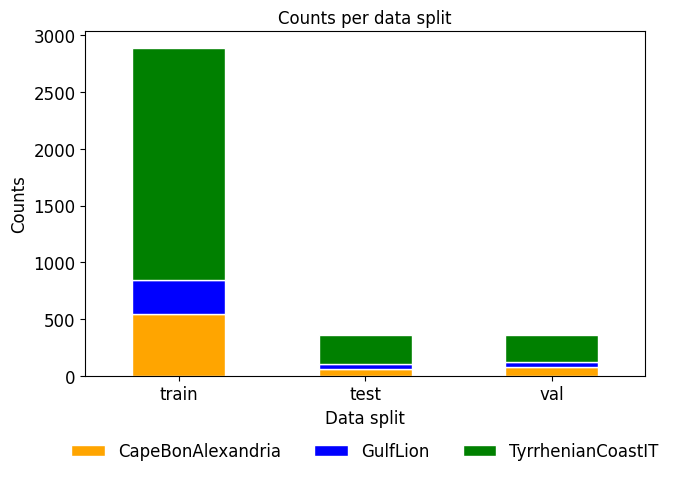

In [14]:
# Consistent split order
pivot = dataset_short.groupby(["split", "AOE"]).size().unstack(fill_value=0)
pivot = pivot.reindex(["train", "test", "val"])
# pivot = pivot.div(pivot.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(7, 5))

pivot.plot(kind="bar", stacked=True, ax=ax, color=PARAMS["colours"], edgecolor="white")

ax.set_xlabel("Data split")
ax.set_ylabel("Counts")
ax.set_title("Counts per data split")

ax.set_xticklabels(pivot.index, rotation=0)
ax.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.15),
          ncol=len(pivot.columns), frameon=False)

plt.tight_layout()
# plt.savefig("stacked_bar_aoe.png", dpi=150)
plt.show()

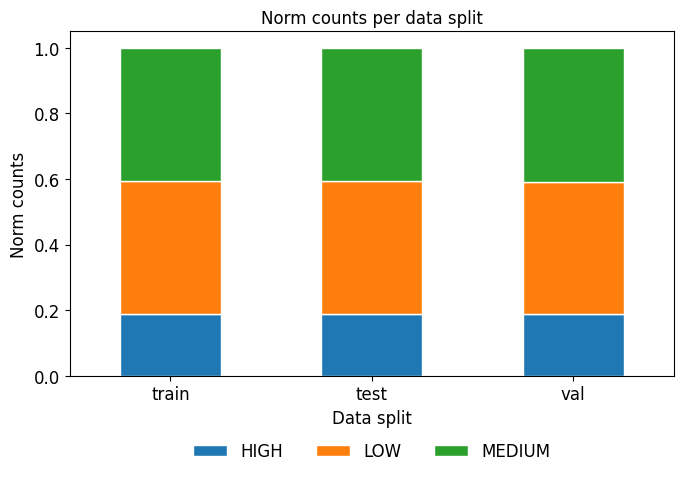

In [ ]:
# Consistent split order
pivot = dataset_short.groupby(["split", "label"]).size().unstack(fill_value=0)
pivot = pivot.reindex(["train", "test", "val"])
pivot = pivot.div(pivot.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(7, 5))

pivot.plot(kind="bar", stacked=True, ax=ax, edgecolor="white")

ax.set_xlabel("Data split")
ax.set_ylabel("Norm counts")
ax.set_title("Norm counts per data split")

ax.set_xticklabels(pivot.index, rotation=0)
ax.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.15),
          ncol=len(pivot.columns), frameon=False)

plt.tight_layout()
plt.show()

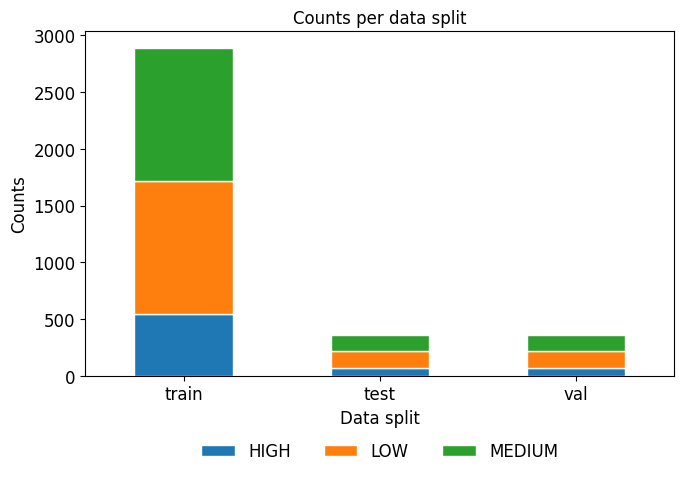

In [16]:
# Consistent split order
pivot = dataset_short.groupby(["split", "label"]).size().unstack(fill_value=0)
pivot = pivot.reindex(["train", "test", "val"])
# pivot = pivot.div(pivot.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(7, 5))

pivot.plot(kind="bar", stacked=True, ax=ax, edgecolor="white")

ax.set_xlabel("Data split")
ax.set_ylabel("Counts")
ax.set_title("Counts per data split")

ax.set_xticklabels(pivot.index, rotation=0)
ax.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.15),
          ncol=len(pivot.columns), frameon=False)

plt.tight_layout()
# plt.savefig("stacked_bar_aoe.png", dpi=150)
plt.show()

0.5937716262975778


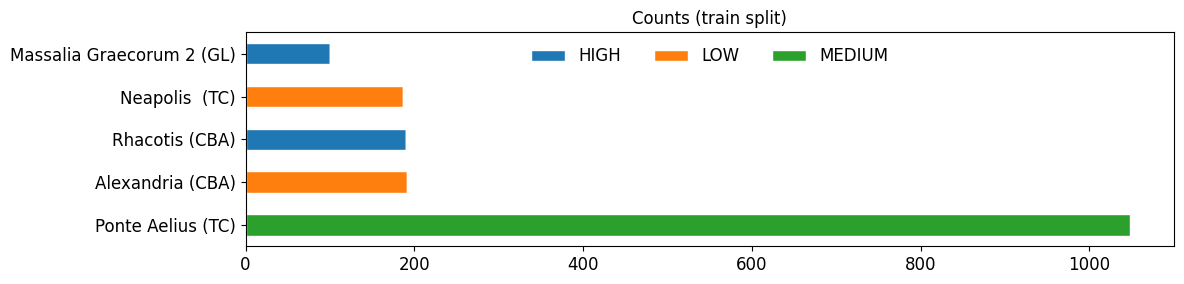

0.5789473684210527


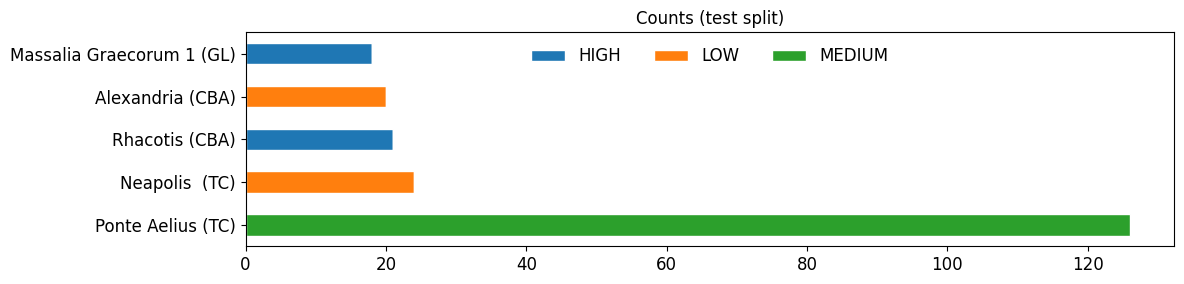

0.5552486187845304


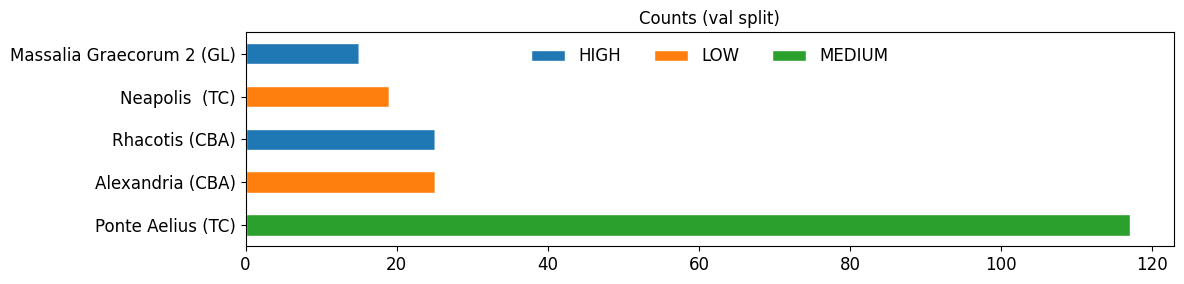

In [18]:
for split in ["train", "test", "val"]:
    df = dataset_short[dataset_short['split']==split]
    pivot = df.groupby(["name_short", "label"]).size().unstack(fill_value=0)
    pivot = pivot.reindex(df["name_short"].unique())
    pivot["COUNT"] = pivot.T.sum(axis=0)
    pivot = pivot.sort_values(by="COUNT", ascending=False)[:5]
    # pivot = pivot.div(pivot.sum(axis=1), axis=0)
    fig, ax = plt.subplots(figsize=(12, 3))
 
    print(pivot["COUNT"].sum()/len(df))
    pivot = pivot.drop(columns="COUNT")
    pivot.plot(kind="barh", stacked=True, ax=ax, edgecolor="white")

    ax.set_ylabel("")
    ax.set_title(f"Counts ({split} split)")

    ax.legend(title="", loc="upper center", bbox_to_anchor=(0.5, 1),
            ncol=len(pivot.columns), frameon=False)

    plt.tight_layout()
    plt.show()